# Exercício 10 — Lista encadeada com operações completas e análise de eficiência

Aluno: Henrique Goldstein Maluhy Mendes Amaral · DR1_AT · Infnet

Para rodar: Ambiente de execução → Executar tudo.

In [1]:
import random
import time

import matplotlib.pyplot as plt
import pandas as pd

random.seed(42)

## 1. A implementação

- Guardo `head`, `tail` e `size`. O `size` é atualizado a cada operação, então `len()` é O(1).
- `search` devolve a posição ou -1, como no exercício 1.
- `delete(value)` remove a primeira ocorrência; se o valor não existe, levanta ValueError, como o `remove` das listas do Python.
- Ao remover o último nó, o `tail` precisa voltar para o nó anterior. Se esquecer disso, o próximo `insert_last` liga o nó novo num nó que já saiu da lista.

In [2]:
class Node:
    def __init__(self, value):
        self.value = value
        self.next = None


class SinglyLinkedList:
    def __init__(self, valores=()):
        self.head = None
        self.tail = None
        self.size = 0
        self.ultimas_comparacoes = 0
        for v in valores:
            self.insert_last(v)

    def __len__(self):
        return self.size

    def __str__(self):
        partes = []
        atual = self.head
        while atual is not None:
            partes.append(repr(atual.value))
            atual = atual.next
        return "[" + " -> ".join(partes) + "]"

    def to_list(self):
        valores, atual = [], self.head
        while atual is not None:
            valores.append(atual.value)
            atual = atual.next
        return valores

    # --- inserção -------------------------------------------------------
    def insert_first(self, value):
        novo = Node(value)
        novo.next = self.head
        self.head = novo
        if self.tail is None:          # lista estava vazia: o novo também é o último
            self.tail = novo
        self.size += 1

    def insert_last(self, value):
        novo = Node(value)
        if self.head is None:
            self.head = novo
        else:
            self.tail.next = novo      # acesso direto ao fim: não percorro nada
        self.tail = novo
        self.size += 1

    # --- busca e remoção por valor ---------------------------------------
    def search(self, value):
        self.ultimas_comparacoes = 0
        posicao, atual = 0, self.head
        while atual is not None:
            self.ultimas_comparacoes += 1
            if atual.value == value:
                return posicao
            atual = atual.next
            posicao += 1
        return -1

    def delete(self, value):
        anterior, atual = None, self.head
        while atual is not None and atual.value != value:
            anterior, atual = atual, atual.next
        if atual is None:
            raise ValueError(f"delete({value!r}): o valor não está na lista")
        self._desligar(anterior, atual)

    # --- operações por posição -----------------------------------------
    def _validar_indice(self, index, maximo, operacao):
        if isinstance(index, bool) or not isinstance(index, int):
            raise TypeError(f"{operacao}: o índice precisa ser inteiro, recebi {index!r}")
        if index < 0 or index > maximo:
            raise IndexError(
                f"{operacao}({index}): índice fora da faixa — a lista tem {self.size} "
                f"elemento(s), então o índice vai de 0 a {maximo}")

    def insert_at(self, index, value):
        # inserir na posição `size` é o mesmo que inserir no fim, por isso o máximo é size
        self._validar_indice(index, self.size, "insert_at")
        if index == 0:
            self.insert_first(value)
        elif index == self.size:
            self.insert_last(value)
        else:
            anterior = self._no_na_posicao(index - 1)
            novo = Node(value)
            novo.next = anterior.next
            anterior.next = novo
            self.size += 1

    def delete_at(self, index):
        if self.size == 0:
            raise IndexError(f"delete_at({index}): a lista está vazia")
        # remover exige que exista um elemento ali, por isso o máximo é size - 1
        self._validar_indice(index, self.size - 1, "delete_at")
        anterior = None if index == 0 else self._no_na_posicao(index - 1)
        atual = self.head if anterior is None else anterior.next
        self._desligar(anterior, atual)
        return atual.value

    # --- auxiliares ------------------------------------------------------
    def _no_na_posicao(self, index):
        atual = self.head
        for _ in range(index):
            atual = atual.next
        return atual

    def _desligar(self, anterior, atual):
        if anterior is None:
            self.head = atual.next
        else:
            anterior.next = atual.next
        if atual is self.tail:
            self.tail = anterior        # o cuidado com o último nó
        self.size -= 1

    def verificar(self):
        """Confere as invariantes: size bate com os nós, e o tail é mesmo o último."""
        contados, ultimo, atual = 0, None, self.head
        while atual is not None:
            contados += 1
            ultimo, atual = atual, atual.next
            assert contados <= self.size, "tem mais nós do que o size diz (ciclo?)"
        assert contados == self.size, f"size = {self.size}, mas há {contados} nós"
        assert self.tail is ultimo, "o tail não aponta para o último nó"
        assert self.tail is None or self.tail.next is None

## 2. Funcionando

In [3]:
lista = SinglyLinkedList()
lista.insert_last(20)
lista.insert_last(30)
lista.insert_first(10)
print("inserções:        ", lista, " tamanho", len(lista))

lista.insert_at(1, 15)
lista.insert_at(len(lista), 40)       # na posição size: vai para o fim
print("insert_at:        ", lista)

print("search(30):       ", lista.search(30), f"({lista.ultimas_comparacoes} comparações)")
print("search(99):       ", lista.search(99), f"({lista.ultimas_comparacoes} comparações)")

lista.delete(15)
print("delete(15):       ", lista)
print("delete_at(0) →    ", lista.delete_at(0), " sobra", lista)

# o caso do tail: removo o último e insiro de novo no fim
lista.delete(40)
lista.insert_last(50)
print("tira o 40, põe 50:", lista)
assert lista.to_list() == [20, 30, 50] and lista.tail.value == 50
lista.verificar()

inserções:         [10 -> 20 -> 30]  tamanho 3
insert_at:         [10 -> 15 -> 20 -> 30 -> 40]
search(30):        3 (4 comparações)
search(99):        -1 (5 comparações)
delete(15):        [10 -> 20 -> 30 -> 40]
delete_at(0) →     10  sobra [20 -> 30 -> 40]
tira o 40, põe 50: [20 -> 30 -> 50]


### Mensagens de erro

In [4]:
lista = SinglyLinkedList([1, 2, 3])
tentativas = [
    ("insert_at(-1, 9)", lambda: lista.insert_at(-1, 9)),
    ("insert_at(4, 9)", lambda: lista.insert_at(4, 9)),
    ("delete_at(3)", lambda: lista.delete_at(3)),
    ("delete_at('0')", lambda: lista.delete_at("0")),
    ("delete(99)", lambda: lista.delete(99)),
    ("delete_at(0) em lista vazia", lambda: SinglyLinkedList().delete_at(0)),
]
for descricao, chamada in tentativas:
    try:
        chamada()
        print(f"{descricao}: ERRO — deveria ter falhado")
    except (IndexError, ValueError, TypeError) as erro:
        print(f"{descricao:<30} → {type(erro).__name__}: {erro}")

assert lista.to_list() == [1, 2, 3]      # nenhuma tentativa inválida mexeu na lista
lista.verificar()

insert_at(-1, 9)               → IndexError: insert_at(-1): índice fora da faixa — a lista tem 3 elemento(s), então o índice vai de 0 a 3
insert_at(4, 9)                → IndexError: insert_at(4): índice fora da faixa — a lista tem 3 elemento(s), então o índice vai de 0 a 3
delete_at(3)                   → IndexError: delete_at(3): índice fora da faixa — a lista tem 3 elemento(s), então o índice vai de 0 a 2
delete_at('0')                 → TypeError: delete_at: o índice precisa ser inteiro, recebi '0'
delete(99)                     → ValueError: delete(99): o valor não está na lista
delete_at(0) em lista vazia    → IndexError: delete_at(0): a lista está vazia


## 3. Teste longo contra um gabarito

1.000 operações sorteadas, com uma lista do Python fazendo as mesmas operações como gabarito.

In [5]:
lista, gabarito = SinglyLinkedList(), []
for passo in range(1000):
    operacao = random.choice(["insert_first", "insert_last", "insert_at", "delete", "delete_at", "search"])
    if operacao == "insert_first":
        lista.insert_first(passo)
        gabarito.insert(0, passo)
    elif operacao == "insert_last":
        lista.insert_last(passo)
        gabarito.append(passo)
    elif operacao == "insert_at":
        i = random.randint(0, len(gabarito))
        lista.insert_at(i, passo)
        gabarito.insert(i, passo)
    elif operacao == "delete" and gabarito:
        valor = random.choice(gabarito)
        lista.delete(valor)
        gabarito.remove(valor)
    elif operacao == "delete_at" and gabarito:
        i = random.randrange(len(gabarito))
        assert lista.delete_at(i) == gabarito.pop(i)
    elif operacao == "search":
        valor = random.randint(0, passo + 1)
        esperado = gabarito.index(valor) if valor in gabarito else -1
        assert lista.search(valor) == esperado
    assert lista.to_list() == gabarito
    lista.verificar()

print(f"1.000 operações: a lista bateu com o gabarito em todos os passos (terminou com {len(lista)} elementos)")

1.000 operações: a lista bateu com o gabarito em todos os passos (terminou com 161 elementos)


## 4. Custo de cada operação

- `insert_first`: O(1)
- `insert_last`: O(1), por causa do tail
- `search` e `delete`: O(n), porque só dá para andar nó a nó (o delete ainda precisa do nó anterior)
- `insert_at(i)` e `delete_at(i)`: O(i)
- `__len__`: O(1)
- `__str__`: O(n)

O delete continua O(n) mesmo com tail: para tirar o último é preciso mudar o `next` do penúltimo, e numa lista simples não dá para voltar do último para o penúltimo. É o que a lista duplamente encadeada resolve (exercício 11).

### Experimento: o custo da busca linear

In [6]:
linhas = []
for n in [1_000, 2_000, 4_000, 8_000, 16_000]:
    valores = list(range(n))
    random.shuffle(valores)
    lista = SinglyLinkedList(valores)

    lista.search(valores[0])
    melhor = lista.ultimas_comparacoes

    soma = 0
    for alvo in random.sample(valores, 200):
        lista.search(alvo)
        soma += lista.ultimas_comparacoes
    medio = soma / 200

    lista.search(-1)
    pior = lista.ultimas_comparacoes

    linhas.append({"n": n, "melhor": melhor, "medio": round(medio), "pior": pior,
                   "medio / n": medio / n, "pior / n": pior / n})

busca = pd.DataFrame(linhas)
busca

,n,melhor,medio,pior,medio / n,pior / n
0,1000,1,507,1000,0.507250,1.0
1,2000,1,1000,2000,0.500243,1.0
2,4000,1,1999,4000,0.499856,1.0
3,8000,1,4312,8000,0.538999,1.0
4,16000,1,7770,16000,0.485653,1.0


Melhor caso: 1 comparação, O(1). Pior caso: n comparações (`pior / n` = 1,0). Caso médio: perto de n/2. Dobrar n dobra o custo: O(n).

## 5. O ponteiro tail

Para medir o efeito do tail, escrevi um `insert_last` que ignora o tail e anda do head até o último nó (como seria sem ele), contando os saltos entre nós.

In [7]:
def insert_last_sem_tail(lista, value):
    """Como seria o insert_last sem o ponteiro tail. Devolve quantos saltos deu."""
    novo = Node(value)
    saltos = 0
    if lista.head is None:
        lista.head = novo
    else:
        atual = lista.head
        while atual.next is not None:     # procura o último andando nó a nó
            atual = atual.next
            saltos += 1
        atual.next = novo
    lista.tail = novo                     # mantenho o tail certo só para o verificar() continuar valendo
    lista.size += 1
    return saltos


linhas = []
for n in [500, 1_000, 2_000, 4_000]:
    com_tail = SinglyLinkedList()
    inicio = time.perf_counter()
    for v in range(n):
        com_tail.insert_last(v)
    tempo_com = time.perf_counter() - inicio

    sem_tail = SinglyLinkedList()
    saltos = 0
    inicio = time.perf_counter()
    for v in range(n):
        saltos += insert_last_sem_tail(sem_tail, v)
    tempo_sem = time.perf_counter() - inicio

    assert com_tail.to_list() == sem_tail.to_list() == list(range(n))
    linhas.append({
        "n": n,
        "saltos_com_tail": 0, "saltos_sem_tail": saltos,
        "teoria (n-1)(n-2)/2": (n - 1) * (n - 2) // 2,
        "saltos_sem_tail / n²": saltos / n**2,
        "ms_com_tail": tempo_com * 1000, "ms_sem_tail": tempo_sem * 1000,
        "sem / com (tempo)": tempo_sem / tempo_com,
    })

tail = pd.DataFrame(linhas)
tail

,n,saltos_com_tail,saltos_sem_tail,teoria (n-1)(n-2)/2,saltos_sem_tail / n²,ms_com_tail,ms_sem_tail,sem / com (tempo)
0,500,0,124251,124251,0.497004,0.2385,3.6577,15.336268
1,1000,0,498501,498501,0.498501,0.2207,13.1558,59.609425
2,2000,0,1997001,1997001,0.499250,0.3502,40.0935,114.487436
3,4000,0,7994001,7994001,0.499625,1.0051,180.4817,179.565914


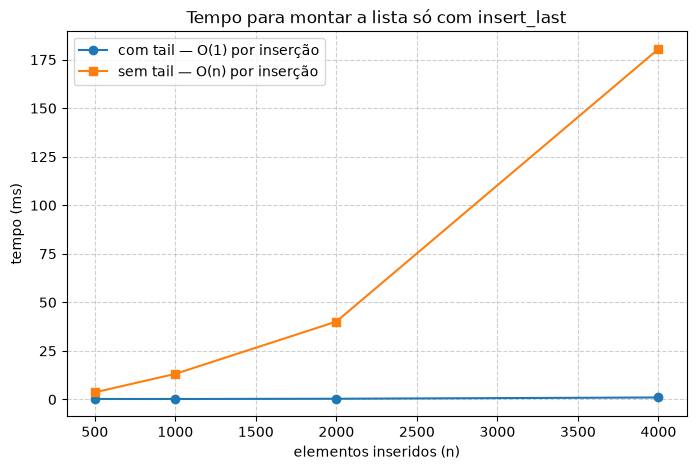

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(tail["n"], tail["ms_com_tail"], marker="o", label="com tail — O(1) por inserção")
plt.plot(tail["n"], tail["ms_sem_tail"], marker="s", label="sem tail — O(n) por inserção")
plt.title("Tempo para montar a lista só com insert_last")
plt.xlabel("elementos inseridos (n)")
plt.ylabel("tempo (ms)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

Com tail: zero saltos, cada `insert_last` é O(1) e montar a lista é O(n). Sem tail: a k-ésima inserção anda k-2 nós, o total bate exatamente com (n-1)(n-2)/2 e `saltos / n²` fica em 0,5, então montar a lista vira O(n²). No tempo, sem tail, dobrar n quadruplica o tempo.

Por isso mantenho o tail: custa um ponteiro por lista e o cuidado de atualizá-lo ao remover o último nó, e em troca o `insert_last` cai de O(n) para O(1). Anexar no fim é o uso mais comum de uma lista (por exemplo, as listas de ocorrências do exercício 12).

## 6. Casos de borda

In [9]:
vazia = SinglyLinkedList()
assert len(vazia) == 0 and str(vazia) == "[]" and vazia.search(1) == -1
vazia.verificar()

# insert_at(0) em lista vazia vira o primeiro e o último ao mesmo tempo
vazia.insert_at(0, "único")
assert vazia.head is vazia.tail and str(vazia) == "['único']"

# esvaziar e reaproveitar
vazia.delete("único")
assert vazia.head is None and vazia.tail is None and len(vazia) == 0
vazia.insert_last("de novo")
assert vazia.to_list() == ["de novo"]
vazia.verificar()

# valores repetidos: search e delete agem na primeira ocorrência
repetidos = SinglyLinkedList([5, 7, 5, 7])
assert repetidos.search(7) == 1
repetidos.delete(5)
assert repetidos.to_list() == [7, 5, 7]

# delete_at no último ajusta o tail
l = SinglyLinkedList([1, 2, 3])
assert l.delete_at(2) == 3 and l.tail.value == 2
l.insert_last(4)
assert l.to_list() == [1, 2, 4]
l.verificar()

# índice booleano é recusado (em Python, True vale 1, mas aqui é quase sempre um engano)
try:
    l.insert_at(True, 0)
except TypeError as erro:
    print(f"insert_at(True, 0) → {erro}")

print("todos os casos de borda passaram")

insert_at(True, 0) → insert_at: o índice precisa ser inteiro, recebi True
todos os casos de borda passaram
